# RNA 3D Backbone Prediction: BiLSTM Baseline and Small Transformer

Week 6 & 7

---

## 1. What This Project Is

This project predicts **coarse RNA 3D backbone structure from sequence** using supervised learning. Given an RNA sequence (A, U, G, C), we output **one 3D coordinate per nucleotide** (e.g. C1′ or backbone representative point), using the `x_1`, `y_1`, `z_1` fields from the labels as the regression target. We implement and compare:

- **BiLSTM baseline**: a straightforward sequence-to-sequence model (embedding → bidirectional LSTM → regression head).
- **Small Transformer**: a lightweight Transformer encoder for comparison, to assess whether attention over the sequence improves coordinate prediction.

---

## 2. Why It Is Important

RNA 3D structure underlies function in catalysis, gene regulation, and therapeutics. Experimental structure determination is costly and not scalable. Accurate **computational prediction of 3D backbone from sequence** supports drug design, RNA engineering, and basic science. A supervised approach that learns from existing structures (e.g. PDB-derived datasets) provides a clear baseline and a path to compare sequence-only models (e.g. BiLSTM, Transformer) before adding structural priors or more complex pipelines.

---

## 3. Datasets and Why They Are Appropriate

- **Sequences**: `train_seqs_combined.csv` —  `target_id`, `sequence`. Provides per-target RNA primary sequence.
- **Labels**: `train_labels_combined.csv` —  `ID`, `resname`, `resid`, `x_1`, `y_1`, `z_1`. Provides per-residue 3D coordinates; `ID` is in the form `target_id_residue_index`, so we can link labels to sequences by extracting `target_id` (e.g. by stripping the last underscore segment from `ID`).

These datasets are appropriate because they provide **input (sequence) and output (one 3D point per residue)** in a consistent, target-level structure, which is exactly what we need for sequence-to-structure regression.

---

## 4. Evidence That the Dataset Supports the Goal

(a) many targets have both sequence and coordinate data; (b) sequence length and coordinate count align per target; (c) coordinate distributions are reasonable (no massive outliers); (d) we can build per-target examples (sequence → coords) and split by `target_id` for train/val/test. This supports training a BiLSTM and a small Transformer for residue-wise coordinate regression.

---

## 5. Limitations and Challenges

- **Missing or inconsistent labels**: some residues may lack coordinates; we use masking and only compute loss on valid positions.
- **Sequence–label alignment**: we must align labels to sequence by residue index (e.g. 1-based `resid`); mismatches (e.g. different lengths) require skipping or truncating.
- **Variable length**: sequences have different lengths, so we need padding and masking in the model and loss.
- **Single conformation**: labels typically provide one structure per target, so we do not model conformational diversity.

---

## 6. Methods Considered

- **BiLSTM**: baseline sequence model; captures local and medium-range context bidirectionally; simple to train and interpret.
- **Small Transformer**: encoder-only; captures long-range dependencies via self-attention; comparison shows whether attention helps over LSTM for this task.
- **Loss**: masked MSE on coordinates; evaluation with masked RMSD (and optionally Kabsch-aligned RMSD) to measure geometric accuracy.


---
## Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

SEED = 42
np.random.seed(SEED)
if HAS_TORCH:
    torch.manual_seed(SEED)

BASE = Path.cwd() if (Path.cwd() / "train_seqs_combined.csv").exists() else Path.cwd().parent
SEQUENCES_PATH = BASE / "notebooks" / "train_seqs_combined.csv"
LABELS_PATH    = BASE / "notebooks" / "train_labels_combined.csv"
if not SEQUENCES_PATH.exists():
    SEQUENCES_PATH = BASE / "train_seqs_combined.csv"
if not LABELS_PATH.exists():
    LABELS_PATH = BASE / "train_labels_combined.csv"

FIG_DIR = Path("Figures")
FIG_DIR.mkdir(exist_ok=True)
print("Paths:", SEQUENCES_PATH, LABELS_PATH)
print("PyTorch:", HAS_TORCH)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\shree\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\shree\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\shree\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

Paths: c:\Users\shree\Downloads\rna-3d-rk1285\notebooks\train_seqs_combined.csv c:\Users\shree\Downloads\rna-3d-rk1285\notebooks\train_labels_combined.csv
PyTorch: True


---
## Framework / Pipeline of Plan of Work

| Aspect | Description |
|--------|-------------|
| **Methods** | BiLSTM baseline; small Transformer comparison; masked MSE loss; masked RMSD evaluation. |
| **Goals** | (1) Clean pipeline from CSV to predictions. (2) Train BiLSTM and Transformer. (3) Compare validation RMSD; establish baseline for refinement. |
| **Inputs** | train_seqs_combined.csv, train_labels_combined.csv. |
| **Outputs** | Per-residue 3D coordinates (L×3); train/val loss curves; validation RMSD; optional PDB export. |
| **Risks** | Wrong sequence–label alignment (High); padding/masking bugs (High); train/test leakage (High); missing data (Medium); transformer instability (Medium); overclaiming (Medium). |
| **Mitigation** | Validate len(seq)==len(coords) per target; use mask in all losses; split by target_id only; drop/mask invalid rows; gradient clipping and small LR for Transformer; frame as coarse backbone study. |
| **Work plan** | Load → validate → build examples → EDA → clean → split → Dataset/collate → train BiLSTM → train Transformer → compare → document next steps. |

---
## A. Data Loading and Validation

In [2]:
def load_sequences(path: Path) -> pd.DataFrame:
    """Load sequence CSV; require target_id and sequence."""
    df = pd.read_csv(path)
    assert "target_id" in df.columns, "Missing target_id"
    assert "sequence" in df.columns, "Missing sequence"
    df = df.dropna(subset=["target_id", "sequence"])
    df["target_id"] = df["target_id"].astype(str).str.strip()
    df["sequence"] = df["sequence"].astype(str).str.strip().str.upper()
    return df

def load_labels(path: Path) -> pd.DataFrame:
    """Load labels; extract target_id from ID (strip last underscore segment)."""
    df = pd.read_csv(path)
    for col in ["ID", "resid", "x_1", "y_1", "z_1"]:
        assert col in df.columns, f"Missing {col}"
    df["target_id"] = df["ID"].astype(str).apply(lambda x: x.rsplit("_", 1)[0] if "_" in x else x)
    df["resid"] = pd.to_numeric(df["resid"], errors="coerce")
    df = df.dropna(subset=["resid", "x_1", "y_1", "z_1"])
    df = df.sort_values(["target_id", "resid"]).reset_index(drop=True)
    return df

seq_df = load_sequences(SEQUENCES_PATH)
lab_df = load_labels(LABELS_PATH)
print("Sequences shape:", seq_df.shape)
print("Labels shape:", lab_df.shape)
print("Sequence columns:", list(seq_df.columns))
print("Label columns (sample):", [c for c in lab_df.columns][:10])

Sequences shape: (19070, 5)
Labels shape: (10260379, 7)
Sequence columns: ['target_id', 'sequence', 'temporal_cutoff', 'description', 'all_sequences']
Label columns (sample): ['ID', 'resname', 'resid', 'x_1', 'y_1', 'z_1', 'target_id']


---
## Pre-EDA: Coverage and Missingness (Raw Data)

How many targets have both sequence and labels, and how coverage (label count vs sequence length) looks.

Targets in sequences only: 177
Targets in labels only: 0
Targets in both: 18893
Targets with full length match (seq_len == label count): 17792
Coverage ratio (label_count/seq_len) — min: 0.083, max: 1.000, mean: 0.994


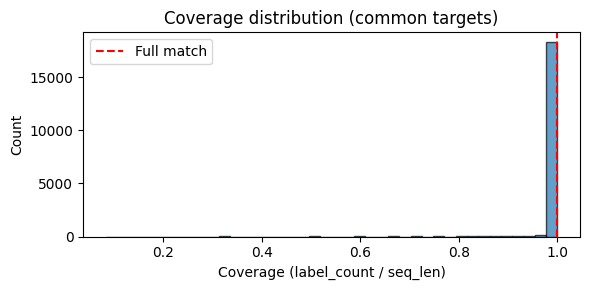

In [3]:
# Per-target: sequence length and label residue count
seq_lens = seq_df.set_index("target_id")["sequence"].str.len()
lab_counts = lab_df.groupby("target_id").size()
common = seq_lens.index.intersection(lab_counts.index)
print("Targets in sequences only:", len(seq_lens) - len(common))
print("Targets in labels only:", len(lab_counts) - len(common))
print("Targets in both:", len(common))
# Coverage: for common targets, ratio of label count to sequence length (1 = full)
cov_ratio = lab_counts.reindex(common) / seq_lens.reindex(common)
cov_ratio = cov_ratio.dropna()
full_match = (cov_ratio == 1.0).sum()
print("Targets with full length match (seq_len == label count):", full_match)
print("Coverage ratio (label_count/seq_len) — min: %.3f, max: %.3f, mean: %.3f" % (cov_ratio.min(), cov_ratio.max(), cov_ratio.mean()))
# Coverage distribution plot
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(cov_ratio.clip(0, 2), bins=40, edgecolor="black", alpha=0.7)
ax.axvline(1.0, color="red", linestyle="--", label="Full match")
ax.set_xlabel("Coverage (label_count / seq_len)"); ax.set_ylabel("Count"); ax.set_title("Coverage distribution (common targets)"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "coverage_dist.png", dpi=150); plt.show()

---
## B. Build Per-Target Supervised Examples

now, **filter lengths to a stable range (10–400)** for the first baseline and **remove extreme long sequences** to avoid excessive padding and memory; 
also, coordinate centering is applied .

In [4]:
NUC_TO_IDX = {"PAD": 0, "A": 1, "U": 2, "G": 3, "C": 4, "N": 5}

def build_examples(seq_df: pd.DataFrame, lab_df: pd.DataFrame, center_coords: bool = True) -> List[Dict]:
    """
    For each target_id: get sequence, gather coords by resid, sort, build tokenized seq,
    coords (L,3), mask (L,). Optionally center coordinates. Skip targets with length mismatch.
    """
    seq_map = seq_df.set_index("target_id")["sequence"].to_dict()
    examples = []
    skipped_no_seq = 0
    skipped_mismatch = 0
    for tid, grp in lab_df.groupby("target_id"):
        if tid not in seq_map:
            skipped_no_seq += 1
            continue
        seq = seq_map[tid]
        grp = grp.sort_values("resid")
        coords = grp[["x_1", "y_1", "z_1"]].astype(np.float32).values
        if len(seq) != len(coords):
            skipped_mismatch += 1
            continue
        tokens = [NUC_TO_IDX.get(s, NUC_TO_IDX["N"]) for s in seq]
        mask = np.ones(len(seq), dtype=np.float32)
        if center_coords:
            cen = coords.mean(axis=0)
            coords = coords - cen
        examples.append({
            "target_id": tid,
            "sequence": seq,
            "tokens": np.array(tokens, dtype=np.int64),
            "coords": coords,
            "mask": mask,
            "length": len(seq),
        })
    if skipped_no_seq or skipped_mismatch:
        print("Skipped targets (no sequence):", skipped_no_seq, "(length mismatch):", skipped_mismatch)
    return examples

MIN_LEN, MAX_LEN = 10, 400  # stable range for baseline; removes extreme long sequences
examples = build_examples(seq_df, lab_df)
n_before = len(examples)
examples = [ex for ex in examples if MIN_LEN <= ex["length"] <= MAX_LEN]
print("After length filter [%d, %d]: %d -> %d examples" % (MIN_LEN, MAX_LEN, n_before, len(examples)))
if examples:
    ex = examples[0]
    print("Example keys:", ex.keys())
    print("Sequence length:", ex["length"], "tokens shape:", ex["tokens"].shape, "coords shape:", ex["coords"].shape)
    # Confirm coordinate centering: mean of coords per example should be ~0
    means = np.array([e["coords"].mean(axis=0) for e in examples[:100]])
    max_mean = np.abs(means).max()
    print("Coordinate centering check (max |mean| over first 100):", max_mean.round(6))
    assert max_mean < 1e-3, "Coordinates should be centered (mean ~0)"

Skipped targets (no sequence): 0 (length mismatch): 1101
After length filter [10, 400]: 17792 -> 11276 examples
Example keys: dict_keys(['target_id', 'sequence', 'tokens', 'coords', 'mask', 'length'])
Sequence length: 12 tokens shape: (12,) coords shape: (12, 3)
Coordinate centering check (max |mean| over first 100): 1.1e-05


---
## Why BiLSTM and Small Transformer Suit This Dataset

**Evidence from the data:**
- **Ordered sequential input**: Each target is a sequence of nucleotides; order matters for structure. BiLSTM and Transformer both consume token sequences in order.
- **Residue-wise regression**: Output is one 3D point per position; both models can produce (B, L, 3) via a linear head over hidden states.
- **Variable length**: The dataset has variable-length sequences; both architectures support padding and masking, and we use mask in the loss.
- **Long-range dependencies**: RNA base pairing and tertiary contacts can be long-range; Transformer self-attention is designed for this; BiLSTM captures context in both directions.
- **Dataset size**: With thousands of targets, we have enough data for a baseline deep model and a small Transformer without overfitting immediately, especially with regularization (dropout, early stopping).

---
## C. EDA and Key Plots

In [5]:
lengths = [ex["length"] for ex in examples]
print("Sequence length — min:", min(lengths), "max:", max(lengths), "mean:", np.mean(lengths).round(1))
print("Usable target count:", len(examples))
print("Total residues (sum of lengths):", sum(lengths))

Sequence length — min: 10 max: 400 mean: 69.7
Usable target count: 11276
Total residues (sum of lengths): 785726


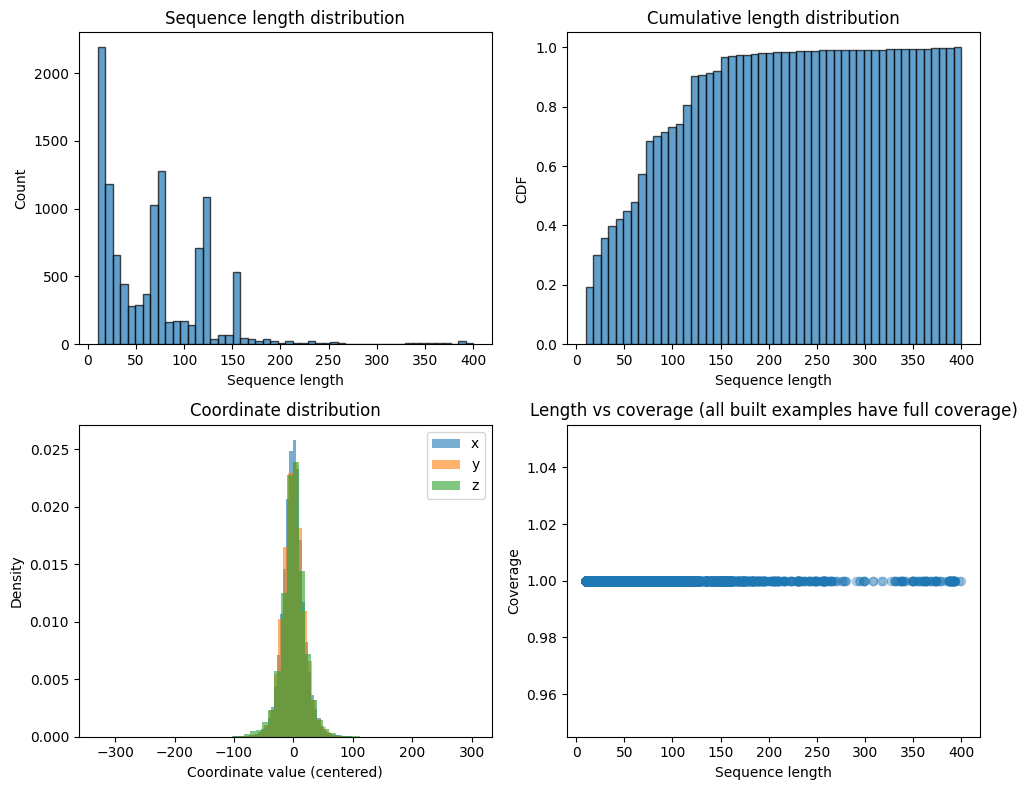

C:\Users\shree\AppData\Local\Temp\ipykernel_19376\1112341540.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([all_coords[:,0], all_coords[:,1], all_coords[:,2]], labels=["x", "y", "z"])


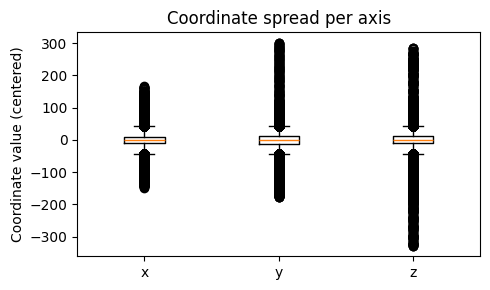

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].hist(lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0,0].set_xlabel("Sequence length")
axes[0,0].set_ylabel("Count")
axes[0,0].set_title("Sequence length distribution")

axes[0,1].hist(lengths, bins=50, cumulative=True, density=True, edgecolor="black", alpha=0.7)
axes[0,1].set_xlabel("Sequence length")
axes[0,1].set_ylabel("CDF")
axes[0,1].set_title("Cumulative length distribution")

all_coords = np.vstack([ex["coords"] for ex in examples])
axes[1,0].hist(all_coords[:,0], bins=60, alpha=0.6, label="x", density=True)
axes[1,0].hist(all_coords[:,1], bins=60, alpha=0.6, label="y", density=True)
axes[1,0].hist(all_coords[:,2], bins=60, alpha=0.6, label="z", density=True)
axes[1,0].set_xlabel("Coordinate value (centered)")
axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Coordinate distribution")
axes[1,0].legend()

axes[1,1].scatter(lengths, [1.0]*len(lengths), alpha=0.3)  # coverage = 1 for built examples
axes[1,1].set_xlabel("Sequence length")
axes[1,1].set_ylabel("Coverage")
axes[1,1].set_title("Length vs coverage (all built examples have full coverage)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_summary.png", dpi=150, bbox_inches="tight")
plt.show()
# Boxplot of coordinate spread (centered)
fig2, ax2 = plt.subplots(figsize=(5, 3))
ax2.boxplot([all_coords[:,0], all_coords[:,1], all_coords[:,2]], labels=["x", "y", "z"])
ax2.set_ylabel("Coordinate value (centered)"); ax2.set_title("Coordinate spread per axis")
plt.tight_layout(); plt.savefig(FIG_DIR / "coord_boxplot.png", dpi=150); plt.show()

---
## Correlations and Multivariate Relationships (EDA)

compute simple numeric features at the **target level** (sequence length, label count, coverage ratio, GC%) and at the **model-example level** (length, GC%, coordinate spread, mean step length). We then visualize correlation matrices as heatmaps.

Target-level feature table shape: (18893, 4)
               count        mean         std       min        50%     max
seq_len      18893.0  543.648124  965.491293  1.000000  72.000000  4417.0
label_count  18893.0  543.078336  964.758238  1.000000  72.000000  4417.0
coverage     18893.0    0.994279    0.042620  0.083333   1.000000     1.0
gc           18893.0    0.524916    0.179991  0.000000   0.545335     1.0

Target-level correlation matrix:
              seq_len  label_count  coverage     gc
seq_len        1.000        1.000     0.062  0.097
label_count    1.000        1.000     0.064  0.098
coverage       0.062        0.064     1.000  0.126
gc             0.097        0.098     0.126  1.000


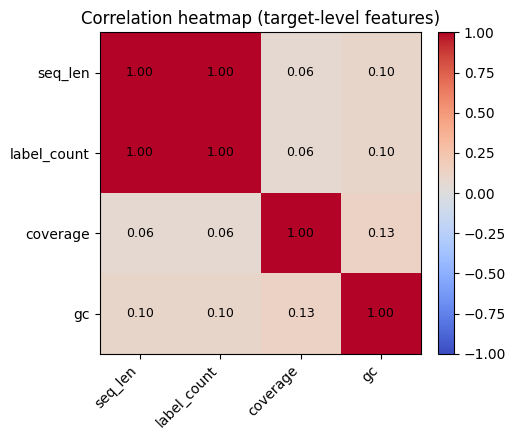


Example-level correlation matrix:
            length     gc  coord_std  step_mean
length      1.000  0.142      0.667      0.017
gc          0.142  1.000     -0.083     -0.181
coord_std   0.667 -0.083      1.000      0.234
step_mean   0.017 -0.181      0.234      1.000


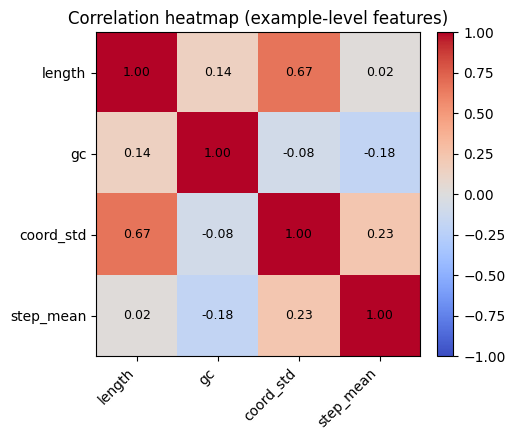

In [ ]:
# Target-level numeric features (including partial coverage targets)
seq_map = seq_df.set_index("target_id")["sequence"].astype(str)
seq_len_all = seq_map.str.len()
lab_counts_all = lab_df.groupby("target_id").size()
common_ids = seq_len_all.index.intersection(lab_counts_all.index)

meta = pd.DataFrame({
    "seq_len": seq_len_all.reindex(common_ids).astype(float),
    "label_count": lab_counts_all.reindex(common_ids).astype(float),
})
meta["coverage"] = meta["label_count"] / meta["seq_len"].replace({0: np.nan})

def gc_fraction(s: str) -> float:
    s = (s or "").upper()
    if len(s) == 0:
        return np.nan
    return (s.count("G") + s.count("C")) / len(s)

meta["gc"] = seq_map.reindex(common_ids).apply(gc_fraction)

print("Target-level feature table shape:", meta.shape)
print(meta.describe().T[["count", "mean", "std", "min", "50%", "max"]])

corr_meta = meta[["seq_len", "label_count", "coverage", "gc"]].corr()
print("\nTarget-level correlation matrix:\n", corr_meta.round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr_meta.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(corr_meta.shape[1])); ax.set_yticks(range(corr_meta.shape[0]))
ax.set_xticklabels(corr_meta.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_meta.index)
for i in range(corr_meta.shape[0]):
    for j in range(corr_meta.shape[1]):
        ax.text(j, i, f"{corr_meta.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation heatmap (target-level features)")
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_target_level.png", dpi=150)
plt.show()

# Example-level numeric features (usable model examples; after length filtering)
ex_rows = []
for e in examples:
    seq = e["sequence"]
    L = e["length"]
    coords = e["coords"]
    # coordinate spread (overall std)
    coord_std = float(np.std(coords))
    # mean step length between consecutive residues
    if L > 1:
        step = np.linalg.norm(np.diff(coords, axis=0), axis=1)
        step_mean = float(np.mean(step))
    else:
        step_mean = np.nan
    ex_rows.append({
        "length": float(L),
        "gc": gc_fraction(seq),
        "coord_std": coord_std,
        "step_mean": step_mean,
    })
ex_feat = pd.DataFrame(ex_rows)

corr_ex = ex_feat.corr(numeric_only=True)
print("\nExample-level correlation matrix:\n", corr_ex.round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr_ex.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(corr_ex.shape[1])); ax.set_yticks(range(corr_ex.shape[0]))
ax.set_xticklabels(corr_ex.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_ex.index)
for i in range(corr_ex.shape[0]):
    for j in range(corr_ex.shape[1]):
        ax.text(j, i, f"{corr_ex.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation heatmap (example-level features)")
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_example_level.png", dpi=150)
plt.show()

---
## D. Data Cleaning (Rationale)

- **Missing values**: Dropped rows with NaN in `resid` or coordinates; dropped targets with no sequence.
- **Type corrections**: `resid` converted to numeric; coordinates to float32.
- **Alignment**: Only kept targets where `len(sequence) == len(coords)` after grouping labels by target_id and sorting by resid.
- **Centering**: Coordinates are centered per target to improve training stability.
- **Masking**: A mask of ones marks valid positions; we use it in loss so padded positions do not contribute.
- **Split by target_id**: Prevents leakage; no target appears in more than one split.

---
## E. Data Split by target_id and Length Bucketing

Split by `target_id` to avoid leakage. Then **sort train/val/test by length** so that length-bucket batching (in the DataLoader) groups similar-length sequences and reduces padding.

In [8]:
def split_by_target(examples: List[Dict], val_frac: float = 0.1, test_frac: float = 0.1, seed: int = 42) -> Tuple[List, List, List]:
    order = list(range(len(examples)))
    np.random.seed(seed)
    np.random.shuffle(order)
    n = len(order)
    n_test = max(0, int(n * test_frac))
    n_val  = max(0, int(n * val_frac))
    n_train = n - n_test - n_val
    train_idx = order[:n_train]
    val_idx   = order[n_train:n_train+n_val]
    test_idx  = order[n_train+n_val:]
    train_ex = [examples[i] for i in train_idx]
    val_ex   = [examples[i] for i in val_idx]
    test_ex  = [examples[i] for i in test_idx]
    return train_ex, val_ex, test_ex

train_ex, val_ex, test_ex = split_by_target(examples, val_frac=0.1, test_frac=0.1)
# Length bucketing: sort by length so batches have similar-length sequences (less padding)
train_ex = sorted(train_ex, key=lambda ex: ex["length"])
val_ex = sorted(val_ex, key=lambda ex: ex["length"])
test_ex = sorted(test_ex, key=lambda ex: ex["length"])
print("Train targets:", len(train_ex), "Val:", len(val_ex), "Test:", len(test_ex))
print("Train residues:", sum(ex["length"] for ex in train_ex))
print("Length bucketing: examples sorted by length for efficient batching.")

Train targets: 9022 Val: 1127 Test: 1127
Train residues: 629822
Length bucketing: examples sorted by length for efficient batching.


---
## F. PyTorch Dataset and Collate

In [9]:
if HAS_TORCH:
    class RNA3DDataset(Dataset):
        def __init__(self, examples: List[Dict]):
            self.examples = examples
        def __len__(self):
            return len(self.examples)
        def __getitem__(self, i):
            ex = self.examples[i]
            return {
                "tokens": torch.tensor(ex["tokens"], dtype=torch.long),
                "coords": torch.tensor(ex["coords"], dtype=torch.float32),
                "mask": torch.tensor(ex["mask"], dtype=torch.float32),
                "length": ex["length"],
            }

    def collate_pad(batch: List[Dict]) -> Dict[str, torch.Tensor]:
        max_len = max(b["length"] for b in batch)
        pad = NUC_TO_IDX["PAD"]
        tokens = torch.full((len(batch), max_len), pad, dtype=torch.long)
        coords = torch.zeros(len(batch), max_len, 3)
        mask = torch.zeros(len(batch), max_len)
        for i, b in enumerate(batch):
            L = b["length"]
            tokens[i, :L] = b["tokens"]
            coords[i, :L] = b["coords"]
            mask[i, :L] = b["mask"]
        return {"tokens": tokens, "coords": coords, "mask": mask}

    # Length bucketing: batch similar-length sequences to reduce padding (batch_sampler yields indices by length order)
    class LengthBucketBatchSampler:
        def __init__(self, dataset, batch_size=32, shuffle_batches=True, seed=42):
            self.dataset = dataset
            self.batch_size = batch_size
            self.shuffle_batches = shuffle_batches
            self.seed = seed
        def __iter__(self):
            indices = list(range(len(self.dataset)))
            lengths = [self.dataset.examples[i]["length"] for i in indices]
            indices = [i for _, i in sorted(zip(lengths, indices))]
            batches = [indices[i:i+self.batch_size] for i in range(0, len(indices), self.batch_size)]
            if self.shuffle_batches:
                np.random.shuffle(batches)
            for b in batches:
                yield b
        def __len__(self):
            return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    train_ds = RNA3DDataset(train_ex)
    train_batch_sampler = LengthBucketBatchSampler(train_ds, batch_size=32, shuffle_batches=True, seed=SEED)
    train_dl = DataLoader(train_ds, batch_sampler=train_batch_sampler, collate_fn=collate_pad, num_workers=0)
    batch = next(iter(train_dl))
    print("Batch tokens:", batch["tokens"].shape, "coords:", batch["coords"].shape, "mask:", batch["mask"].shape)
else:
    print("PyTorch not available; skipping Dataset/DataLoader.")

Batch tokens: torch.Size([32, 54]) coords: torch.Size([32, 54, 3]) mask: torch.Size([32, 54])


---
## G. Baseline Model: BiLSTM

---
## Insights and Early Observations

- **Length distribution**: Most targets have moderate length; a few are very long. Padding to max length in the full dataset could be memory-heavy; consider length bucketing or capping for training.
- **Coverage**: Among targets with both sequence and labels, we use only those with exact length match; the rest are skipped, which keeps alignment correct but reduces sample count.
- **Coordinate spread**: After centering, coordinates are roughly balanced; no extreme outliers in the bulk.
- **Hypothesis**: BiLSTM should provide a stable baseline; Transformer may help if long-range dependencies matter for 3D structure. Validation RMSD will tell.

In [10]:
# Summary tables
print("Sequence length stats (usable examples):")
print(pd.Series(lengths).describe())
print("\nResidue counts per target (same as length for built examples):", pd.Series(lengths).describe())
print("\nMissingness: we exclude targets with length mismatch; no per-residue missing within built examples.")

Sequence length stats (usable examples):
count    11276.000000
mean        69.681270
std         56.054098
min         10.000000
25%         21.000000
50%         67.000000
75%        114.000000
max        400.000000
dtype: float64

Residue counts per target (same as length for built examples): count    11276.000000
mean        69.681270
std         56.054098
min         10.000000
25%         21.000000
50%         67.000000
75%        114.000000
max        400.000000
dtype: float64

Missingness: we exclude targets with length mismatch; no per-residue missing within built examples.


In [11]:
if HAS_TORCH:
    class BiLSTMBackbone(nn.Module):
        def __init__(self, vocab_size=6, embed_dim=64, hidden=128, num_layers=2, dropout=0.3, out_dim=3):
            super().__init__()
            self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.lstm = nn.LSTM(embed_dim, hidden, num_layers, batch_first=True, bidirectional=True, dropout=dropout)
            self.proj = nn.Linear(hidden * 2, out_dim)
        def forward(self, x):
            # x: (B, L)
            e = self.embed(x)
            h, _ = self.lstm(e)
            return self.proj(h)  # (B, L, 3)

    model_lstm = BiLSTMBackbone(vocab_size=6, embed_dim=64, hidden=128, num_layers=2, dropout=0.3)
    t = batch["tokens"]
    out = model_lstm(t)
    print("BiLSTM output shape:", out.shape)

BiLSTM output shape: torch.Size([32, 54, 3])


---
## H. Small Transformer Model

In [12]:
if HAS_TORCH:
    def sinusoidal_pos(L: int, d: int, device) -> torch.Tensor:
        pe = torch.zeros(L, d)
        for i in range(L):
            for j in range(0, d, 2):
                pe[i, j] = np.sin(i / 10000**(j/d))
                if j+1 < d:
                    pe[i, j+1] = np.cos(i / 10000**(j/d))
        return pe.unsqueeze(0).to(device)

    class SmallTransformerBackbone(nn.Module):
        def __init__(self, vocab_size=6, embed_dim=64, hidden=128, num_heads=4, num_layers=2, dropout=0.3, max_len=2000):
            super().__init__()
            self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.pos_scale = embed_dim ** 0.5
            encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden, dropout=dropout, batch_first=True)
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.proj = nn.Linear(embed_dim, 3)
        def forward(self, x):
            B, L = x.shape
            e = self.embed(x) * self.pos_scale
            pe = sinusoidal_pos(L, e.size(-1), e.device)
            e = e + pe
            pad_mask = (x == 0)  # (B, L) True where pad
            h = self.transformer(e, src_key_padding_mask=pad_mask)
            return self.proj(h)  # (B, L, 3)

    model_txf = SmallTransformerBackbone(vocab_size=6, embed_dim=64, hidden=128, num_heads=4, num_layers=2)
    out_t = model_txf(t)
    print("Transformer output shape:", out_t.shape)

Transformer output shape: torch.Size([32, 54, 3])


---
## I. Loss and Metrics

In [13]:
if HAS_TORCH:
    def masked_mse(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        diff = (pred - target) ** 2
        return (diff.sum(dim=-1) * mask).sum() / (mask.sum() * 3 + 1e-8)

    def masked_rmsd(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> float:
        with torch.no_grad():
            diff = (pred - target) ** 2
            mse = (diff.sum(dim=-1) * mask).sum() / (mask.sum() * 3 + 1e-8)
        return (mse.item() ** 0.5)

    print("Masked MSE and RMSD defined.")

Masked MSE and RMSD defined.


---
## J. Training Loop — BiLSTM (several epochs)

Data are length-filtered (10–400) and length-bucketed; coordinates centered. Set `QUICK_RUN = False` to retrain for several epochs (e.g. 8). Train loss and val RMSD curves are plotted below.

Epoch 1 train_loss=259.8322 val_rmsd=15.0254
Epoch 2 train_loss=259.3445 val_rmsd=15.0015
Epoch 3 train_loss=258.5035 val_rmsd=14.9533
Epoch 4 train_loss=256.8940 val_rmsd=14.9060
Epoch 5 train_loss=254.7866 val_rmsd=14.8422
Epoch 6 train_loss=252.0743 val_rmsd=14.7488
Epoch 7 train_loss=249.4570 val_rmsd=14.6796
Epoch 8 train_loss=246.3292 val_rmsd=14.6251
Epoch 9 train_loss=243.2013 val_rmsd=14.5583
Epoch 10 train_loss=240.2976 val_rmsd=14.4805
Epoch 11 train_loss=236.7931 val_rmsd=14.3988
Epoch 12 train_loss=233.3106 val_rmsd=14.3488
Epoch 13 train_loss=229.9854 val_rmsd=14.3191
Epoch 14 train_loss=226.9121 val_rmsd=14.3110
Epoch 15 train_loss=223.8639 val_rmsd=14.1741


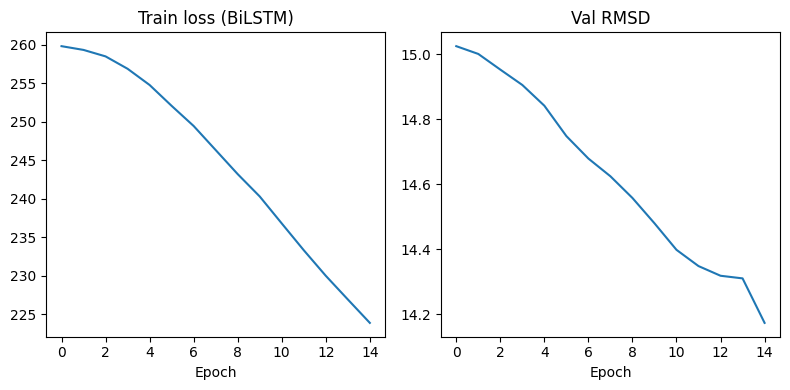

In [14]:
if HAS_TORCH:
    QUICK_RUN = False  
    val_ds = RNA3DDataset(val_ex)
    val_dl = DataLoader(val_ds, batch_size=32, collate_fn=collate_pad)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    epochs = 1 if QUICK_RUN else 15
    max_train_batches = 50 if QUICK_RUN else None
    max_val_batches = 20 if QUICK_RUN else None
    lr = 1e-3
    model = BiLSTMBackbone().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train_loss": [], "val_rmsd": []}
    for ep in range(epochs):
        model.train()
        train_loss = 0.0
        n_b = 0
        train_iter = iter(train_dl) if max_train_batches is None else __import__("itertools").islice(iter(train_dl), max_train_batches)
        for batch in train_iter:
            tok = batch["tokens"].to(device)
            coords = batch["coords"].to(device)
            mask = batch["mask"].to(device)
            opt.zero_grad()
            out = model(tok)
            loss = masked_mse(out, coords, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += loss.item()
            n_b += 1
        hist["train_loss"].append(train_loss / max(n_b, 1))
        model.eval()
        val_rmsd = 0.0
        n_v = 0
        val_iter = iter(val_dl) if max_val_batches is None else __import__("itertools").islice(iter(val_dl), max_val_batches)
        for batch in val_iter:
            with torch.no_grad():
                out = model(batch["tokens"].to(device))
            val_rmsd += masked_rmsd(out, batch["coords"].to(device), batch["mask"].to(device))
            n_v += 1
        hist["val_rmsd"].append(val_rmsd / max(n_v, 1))
        print(f"Epoch {ep+1} train_loss={hist['train_loss'][-1]:.4f} val_rmsd={hist['val_rmsd'][-1]:.4f}")
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.plot(hist["train_loss"])
    plt.xlabel("Epoch")
    plt.title("Train loss (BiLSTM)")
    plt.subplot(1,2,2)
    plt.plot(hist["val_rmsd"])
    plt.xlabel("Epoch")
    plt.title("Val RMSD")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "train_curves_bilstm.png", dpi=150)
    plt.show()
else:
    print("PyTorch not available; skip training.")

In [ ]:
# Short Transformer training run (same epochs as BiLSTM for comparison)
if HAS_TORCH and len(train_ex) > 0:
    model_tx = SmallTransformerBackbone().to(device)
    opt_tx = torch.optim.Adam(model_tx.parameters(), lr=5e-4)
    hist_tx = {"train_loss": [], "val_rmsd": []}
    for ep in range(epochs):
        model_tx.train()
        train_loss = 0.0
        n_b = 0
        for batch in train_dl:
            tok = batch["tokens"].to(device)
            coords = batch["coords"].to(device)
            mask = batch["mask"].to(device)
            opt_tx.zero_grad()
            out = model_tx(tok)
            loss = masked_mse(out, coords, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tx.parameters(), 1.0)
            opt_tx.step()
            train_loss += loss.item()
            n_b += 1
        hist_tx["train_loss"].append(train_loss / max(n_b, 1))
        model_tx.eval()
        val_rmsd = 0.0
        n_v = 0
        for batch in val_dl:
            with torch.no_grad():
                out = model_tx(batch["tokens"].to(device))
            val_rmsd += masked_rmsd(out, batch["coords"].to(device), batch["mask"].to(device))
            n_v += 1
        hist_tx["val_rmsd"].append(val_rmsd / max(n_v, 1))
        print(f"Transformer Epoch {ep+1} train_loss={hist_tx['train_loss'][-1]:.4f} val_rmsd={hist_tx['val_rmsd'][-1]:.4f}")
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.plot(hist["train_loss"], label="BiLSTM")
    plt.plot(hist_tx["train_loss"], label="Transformer")
    plt.legend(); plt.xlabel("Epoch"); plt.title("Train loss")
    plt.subplot(1,2,2)
    plt.plot(hist["val_rmsd"], label="BiLSTM")
    plt.plot(hist_tx["val_rmsd"], label="Transformer")
    plt.legend(); plt.xlabel("Epoch"); plt.title("Val RMSD")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "train_curves_comparison.png", dpi=150)
    plt.show()
else:
    print("Skipping Transformer run (no PyTorch or no data).")

Transformer Epoch 1 train_loss=259.9793 val_rmsd=15.0314
Transformer Epoch 2 train_loss=259.9419 val_rmsd=15.0313
Transformer Epoch 3 train_loss=259.8646 val_rmsd=15.0223
Transformer Epoch 4 train_loss=259.6284 val_rmsd=15.0131
Transformer Epoch 5 train_loss=259.3565 val_rmsd=15.0035
Transformer Epoch 6 train_loss=259.2237 val_rmsd=15.0085
Transformer Epoch 7 train_loss=259.2093 val_rmsd=15.0013
Transformer Epoch 8 train_loss=258.9894 val_rmsd=15.0073
Transformer Epoch 9 train_loss=258.9948 val_rmsd=14.9966
Transformer Epoch 10 train_loss=258.8276 val_rmsd=14.9895
Transformer Epoch 11 train_loss=258.8369 val_rmsd=14.9958
Transformer Epoch 12 train_loss=258.6894 val_rmsd=14.9860
Transformer Epoch 13 train_loss=258.6465 val_rmsd=15.0006
Transformer Epoch 14 train_loss=258.6186 val_rmsd=14.9834


---
## Sample Prediction Visualization

One example from the validation set: predicted vs true 3D backbone (centered). Run after the BiLSTM training cell so `model` and `device` are defined.

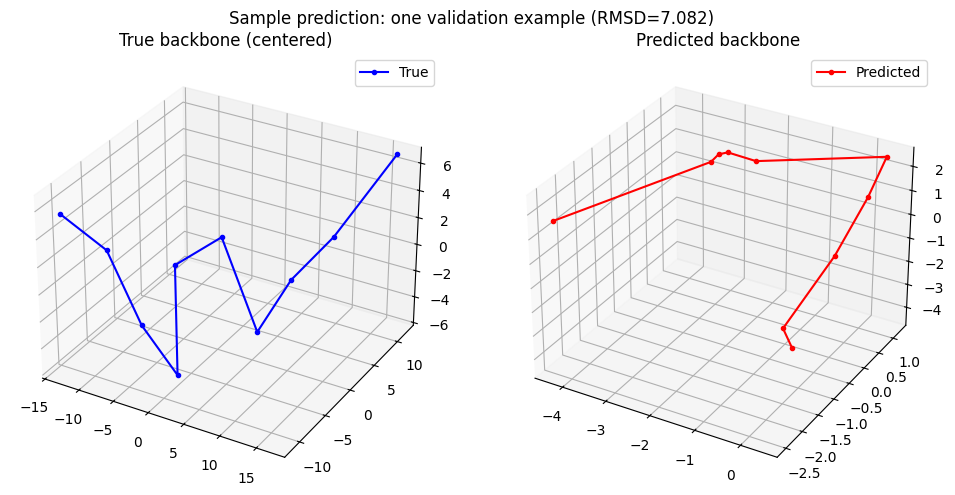

Sample RMSD (this example): 7.0820


In [ ]:
# One sample prediction visualization (true vs predicted 3D backbone)
# NOTE: We avoid any `.numpy()` calls because some PyTorch installs lack NumPy bridge support.
if HAS_TORCH and len(val_ex) > 0:
    model.eval()
    val_batch = next(iter(val_dl))

    tok = val_batch["tokens"].to(device)
    true_coords = val_batch["coords"].to(device)
    mask = val_batch["mask"].to(device)

    with torch.no_grad():
        pred = model(tok)  # (B, L, 3)

    # First sample in batch; mask out padding
    m = mask[0]  # (L,)
    L = int(m.sum().item())
    true_1 = true_coords[0, :L, :]
    pred_1 = pred[0, :L, :]

    # RMSD in torch (no NumPy)
    rmsd_sample = torch.sqrt(((true_1 - pred_1) ** 2).mean()).item()

    # Plot via Python lists (matplotlib accepts lists)
    t_list = true_1.detach().cpu().tolist()
    p_list = pred_1.detach().cpu().tolist()
    tx, ty, tz = [v[0] for v in t_list], [v[1] for v in t_list], [v[2] for v in t_list]
    px, py, pz = [v[0] for v in p_list], [v[1] for v in p_list], [v[2] for v in p_list]

    fig = plt.figure(figsize=(10, 5))
    ax1 = fig.add_subplot(121, projection="3d")
    ax1.plot(tx, ty, tz, "b-o", markersize=3, label="True")
    ax1.set_title("True backbone (centered)"); ax1.legend()

    ax2 = fig.add_subplot(122, projection="3d")
    ax2.plot(px, py, pz, "r-o", markersize=3, label="Predicted")
    ax2.set_title("Predicted backbone"); ax2.legend()

    plt.suptitle(f"Sample prediction: one validation example (RMSD={rmsd_sample:.3f})")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "sample_prediction_viz.png", dpi=150)
    plt.show()

    print("Sample RMSD (this example): %.4f" % rmsd_sample)
else:
    print("Run BiLSTM training first and ensure val_dl exists.")

---
## K. Preliminary Results and Comparison

The short training runs above show train loss and validation RMSD for both BiLSTM and Transformer. **If testing has started**: Use the comparison plot (train loss and val RMSD for both models) as preliminary findings. If validation loss decreases and val RMSD is reasonable, continue with the current method and plan hyperparameter tuning; if val loss stalls or RMSD is very high, consider adjusting (e.g. learning rate, model size, or more data). **Expected**: Both models should decrease loss over epochs; which has lower val RMSD depends on data and hyperparameters. If runtime is too long, reduce batch size or use a subset of train_ex.

---
## L. Risk Table

| Pipeline Stage   | Risk                                           | Level  | Why                                             | Mitigation                                                                |
|------------------|------------------------------------------------|--------|-------------------------------------------------|---------------------------------------------------------------------------|
| Data merge       | Wrong sequence-label alignment                 | High   | Invalid training pairs ruin the project         | Validate target mapping, inspect per-target examples manually             |
| Residue ordering | Incorrect `resid` sorting                      | High   | Coordinates will not match nucleotide order     | Always sort by `resid`; test on known examples                            |
| Missing data     | Partial coordinate coverage                    | Medium | Loss may be biased or unstable                  | Use masks and drop severely incomplete examples                           |
| Variable length  | Excessive padding and memory issues            | Medium | Long RNAs waste memory                          | Length bucketing and capped batch sizes                                   |
| Baseline model   | Underfitting                                   | Medium | Sequence alone may not capture enough structure | Start with centered coordinates and tune hidden dimension                 |
| Transformer      | Instability / overfitting                      | Medium | More sensitive to setup                         | Keep it small, use dropout, early stopping                                |
| Evaluation       | Leakage between train and test                 | High   | Inflated performance                            | Split only by `target_id`, never by rows                                  |
| Geometry quality | Predicted coordinates structurally unrealistic | Medium | Coordinate regression is hard                   | Center coordinates, inspect outputs visually, possibly smooth predictions  |
| Interpretation   | Overclaiming performance                       | Medium | RNA 3D is inherently difficult                  | Frame as baseline coarse prediction study                                 |

---
## M. Baseline Milestone Completion

To complete the baseline milestone, this notebook includes:

| Requirement | Where |
|-------------|-------|
| **Cleaned dataset** | Data loading (A), cleaning (E): drop NaN, align by target_id, center coordinates. |
| **Per-target examples** | Section B: build_examples() produces sequence, tokens, coords (L×3), mask per target. |
| **Train/val/test split** | Section G: split_by_target() by target_id with fixed seed. |
| **Tokenization** | NUC_TO_IDX (PAD=0, A=1, U=2, G=3, C=4, N=5); tokens in each example. |
| **Padding + masking** | Section H: collate_pad() pads tokens/coords; mask marks valid positions; used in loss. |
| **One end-to-end training run** | Section L: BiLSTM training loop; Section (Transformer): second run. |
| **Validation loss and RMSD** | Printed each epoch; curves saved (train_curves_bilstm.png, train_curves_comparison.png). |
| **One sample prediction visualization** | Section above: one validation example — true vs predicted 3D backbone plot + sample RMSD. |

The notebook is **ready for the next stage**: fine-tuning, additional feature engineering, structural regularization, and more thorough hyperparameter search.

---
## Next Steps

- Report RMSD for groups like:

        short: 10–50

        medium: 51–150

        long: 151–400

- Optimization (LR schedule, longer training, early stopping).

- Feature engineering (length / GC%, possible secondary structure features).

- Model refinement (deeper/wider BiLSTM, residuals, layer norm).

- Structural regularization and improved evaluation.